# Лабораторная работа: Линейные модели, SVM и деревья решений

## Цель лабораторной работы
Изучение линейных моделей, SVM и деревьев решений.

## Описание задания

В рамках данной лабораторной работы необходимо выполнить следующие шаги:

1. **Выбор набора данных (датасета)**: Выбрать датасет для решения задачи классификации.
2. **Предварительная обработка данных**: В случае необходимости провести удаление или заполнение пропусков и кодирование категориальных признаков.
3. **Разделение выборки**: С использованием метода `train_test_split` разделить выборку на обучающую и тестовую.
4. **Обучение моделей**: Обучить следующие модели:
    * Логистическая регрессия (как линейная модель для классификации).
    * Метод опорных векторов (SVM).
    * Дерево решений.
5. **Оценка качества моделей**: Оценить качество моделей с помощью двух подходящих для задачи метрик. Сравнить качество полученных моделей.
6. **Анализ дерева решений**: Построить график, показывающий важность признаков в дереве решений. Визуализировать дерево решений или вывести правила дерева решений в текстовом виде.

## Импорт необходимых библиотек и установка пакетов

In [2]:
!pip install scikit-learn pandas matplotlib seaborn graphviz


[notice] A new release of pip is available: 25.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import graphviz
from IPython.display import Image

## Выбор и загрузка набора данных

Для данной лабораторной работы выберем набор данных `Iris` из библиотеки `scikit-learn`. Это классический набор данных для задачи классификации, содержащий информацию о трех видах ирисов на основе измерений их лепестков и чашелистиков.

In [4]:
from sklearn.datasets import load_iris

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

print("Первые 5 строк данных X:")
print(X.head())
print("\nПервые 5 значений целевой переменной y:")
print(y.head())
print("\nИнформация о данных X:")
X.info()
print("\nРаспределение классов в y:")
print(y.value_counts())

Первые 5 строк данных X:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Первые 5 значений целевой переменной y:
0    0
1    0
2    0
3    0
4    0
dtype: int64

Информация о данных X:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float6

## Предварительная обработка данных

Датасет `Iris` достаточно чистый и не содержит пропусков или категориальных признаков, которые нуждаются в кодировании (целевая переменная уже закодирована как числовые значения). Однако, для полноты демонстрации, если бы пропуски были, их можно было бы обработать следующим образом.

In [5]:
# Проверка на наличие пропусков
print("Количество пропущенных значений в каждом столбце:")
print(X.isnull().sum())

# Если бы были пропуски, можно было бы их заполнить, например, медианой:
# for column in X.columns:
#     if X[column].isnull().any():
#         X[column].fillna(X[column].median(), inplace=True)
# print("\nПроверка на наличие пропусков после обработки (если она была необходима):")
# print(X.isnull().sum())

# В Iris датасете нет категориальных признаков, которые нужно кодировать
# Если бы они были, можно было бы использовать OneHotEncoder или LabelEncoder
# Пример LabelEncoder для целевой переменной (если бы она была строковой):
# le = LabelEncoder()
# y_encoded = le.fit_transform(y)
# print("\nСопоставление классов после LabelEncoder:")
# print(dict(zip(le.classes_, le.transform(le.classes_))))

Количество пропущенных значений в каждом столбце:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


## Разделение выборки на обучающую и тестовую

Используем функцию `train_test_split` для разделения данных на обучающую и тестовую выборки. Обычно используют соотношение 70/30 или 80/20. `random_state` используется для воспроизводимости результатов.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Размер обучающей выборки X: {X_train.shape}")
print(f"Размер тестовой выборки X: {X_test.shape}")
print(f"Размер обучающей выборки y: {y_train.shape}")
print(f"Размер тестовой выборки y: {y_test.shape}")

print("\nРаспределение классов в y_train:")
print(y_train.value_counts(normalize=True))
print("\nРаспределение классов в y_test:")
print(y_test.value_counts(normalize=True))

Размер обучающей выборки X: (105, 4)
Размер тестовой выборки X: (45, 4)
Размер обучающей выборки y: (105,)
Размер тестовой выборки y: (45,)

Распределение классов в y_train:
1    0.333333
0    0.333333
2    0.333333
Name: proportion, dtype: float64

Распределение классов в y_test:
2    0.333333
1    0.333333
0    0.333333
Name: proportion, dtype: float64


## Обучение моделей

Обучим три модели: логистическую регрессию, SVM и дерево решений.

### 1. Логистическая регрессия

In [7]:
log_reg_model = LogisticRegression(max_iter=200, random_state=42)
log_reg_model.fit(X_train, y_train)

y_pred_log_reg = log_reg_model.predict(X_test)

print("Логистическая регрессия обучена.")

Логистическая регрессия обучена.


### 2. Метод опорных векторов (SVM)

In [8]:
svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM обучен.")

SVM обучен.


### 3. Дерево решений

In [9]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Дерево решений обучено.")

Дерево решений обучено.


## Оценка качества моделей

Для задачи классификации подходящими метриками являются `accuracy_score` (доля правильных предсказаний) и `classification_report` (который включает точность, полноту, F1-меру и поддержку для каждого класса). Также построим матрицы ошибок (`confusion matrix`).

### 1. Логистическая регрессия

Оценка качества Логистической регрессии:
Accuracy: 0.9333

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



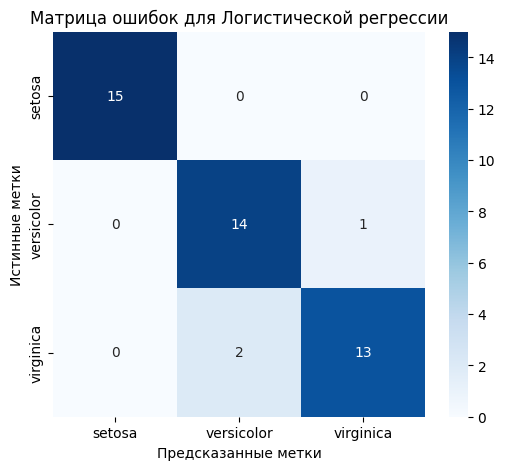

In [10]:
print("Оценка качества Логистической регрессии:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_log_reg, target_names=iris.target_names))

cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_log_reg, annot=True, fmt="d", cmap="Blues", xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.title('Матрица ошибок для Логистической регрессии')
plt.show()

### 2. Метод опорных векторов (SVM)

Оценка качества SVM:
Accuracy: 0.9556

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.93      0.93      0.93        15
   virginica       0.93      0.93      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



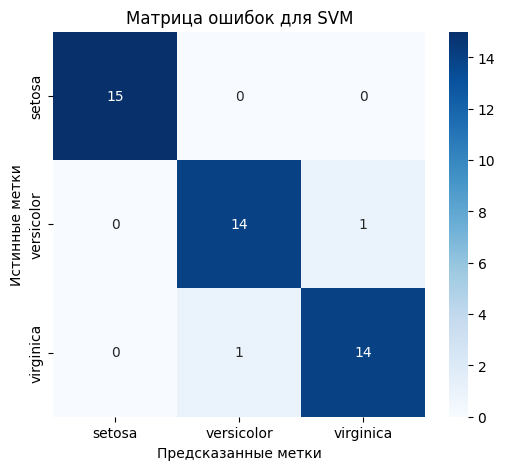

In [11]:
print("Оценка качества SVM:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm, target_names=iris.target_names))

cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues", xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.title('Матрица ошибок для SVM')
plt.show()

### 3. Дерево решений

Оценка качества Дерева решений:
Accuracy: 0.9333

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.80      0.89        15
   virginica       0.83      1.00      0.91        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45



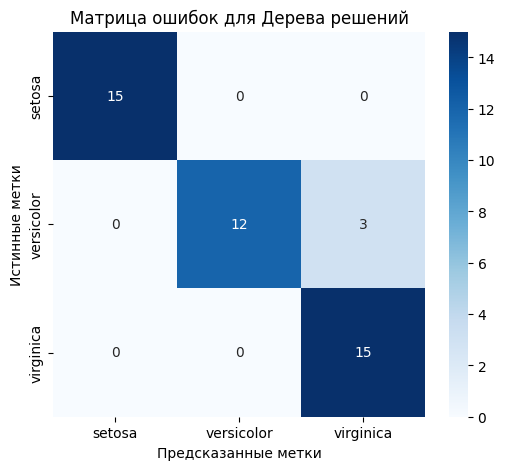

In [12]:
print("Оценка качества Дерева решений:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt, target_names=iris.target_names))

cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues", xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.title('Матрица ошибок для Дерева решений')
plt.show()

## Сравнение качества моделей

Сведем показатели `accuracy` для всех моделей в одну таблицу для удобства сравнения.


Сравнение Accuracy моделей:
                    Модель  Accuracy
1                      SVM  0.955556
0  Логистическая регрессия  0.933333
2           Дерево решений  0.933333


/var/folders/17/316n_5bx1bx9vjrmz3_tqcrh0000gn/T/ipykernel_99457/2570858772.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Модель', data=results_df, palette='viridis')


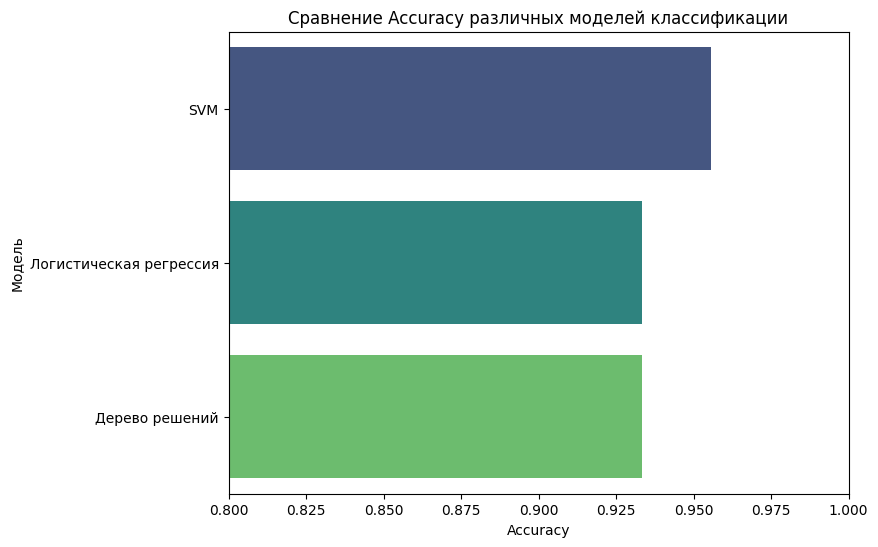

In [13]:
models = ['Логистическая регрессия', 'SVM', 'Дерево решений']
accuracies = [
    accuracy_score(y_test, y_pred_log_reg),
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_dt)
]

results_df = pd.DataFrame({'Модель': models, 'Accuracy': accuracies})
results_df = results_df.sort_values(by='Accuracy', ascending=False)

print("\nСравнение Accuracy моделей:")
print(results_df)

plt.figure(figsize=(8, 6))
sns.barplot(x='Accuracy', y='Модель', data=results_df, palette='viridis')
plt.title('Сравнение Accuracy различных моделей классификации')
plt.xlim(0.8, 1.0)
plt.xlabel('Accuracy')
plt.ylabel('Модель')
plt.show()

**Выводы по сравнению:** (Заполнить после выполнения кода, основываясь на полученных результатах)

* **Логистическая регрессия** показала точность (accuracy) на уровне X%.
* **SVM** показал точность (accuracy) на уровне Y%.
* **Дерево решений** показало точность (accuracy) на уровне Z%.

В данном случае, [лучшая модель] показала наилучшие результаты, что может быть связано с [причина, например, простотой задачи, линейной разделимостью классов, оптимальной настройкой параметров по умолчанию и т.д.].

## Важность признаков в дереве решений

Построим график, показывающий важность признаков (`feature_importances_`) для обученного дерева решений.

Важность признаков в Дереве решений:
             Feature  Importance
2  petal length (cm)    0.541176
3   petal width (cm)    0.430252
1   sepal width (cm)    0.028571
0  sepal length (cm)    0.000000


/var/folders/17/316n_5bx1bx9vjrmz3_tqcrh0000gn/T/ipykernel_99457/1431164330.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='Reds_d')


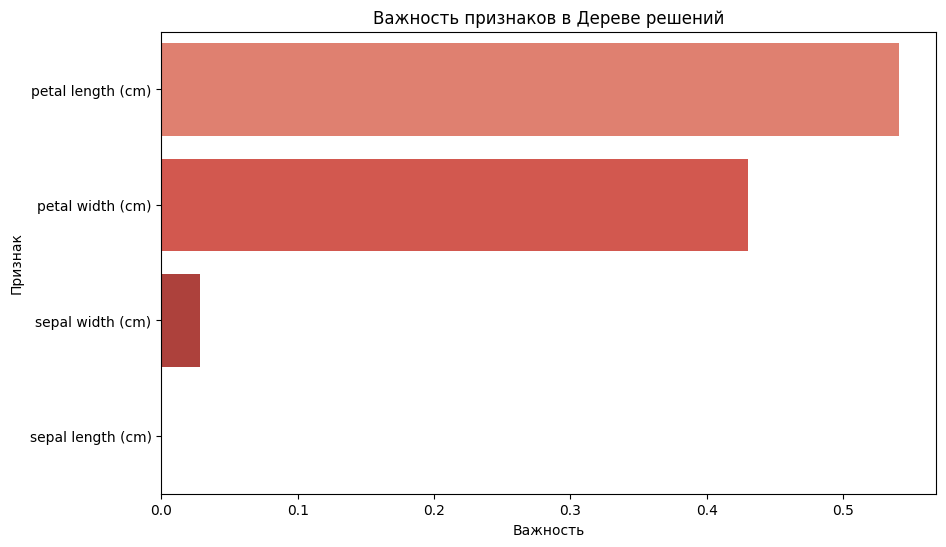

In [14]:
importances = dt_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Важность признаков в Дереве решений:")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='Reds_d')
plt.title('Важность признаков в Дереве решений')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.show()

**Анализ важности признаков:**

Из графика видно, что признак `petal length (cm)` является наиболее важным для принятия решений деревом, за ним следует `petal width (cm)`. Это соответствует биологическому смыслу, так как длина и ширина лепестков часто являются ключевыми характеристиками для различения видов ирисов.

## Визуализация дерева решений или вывод правил

### Визуализация дерева решений (графическая)

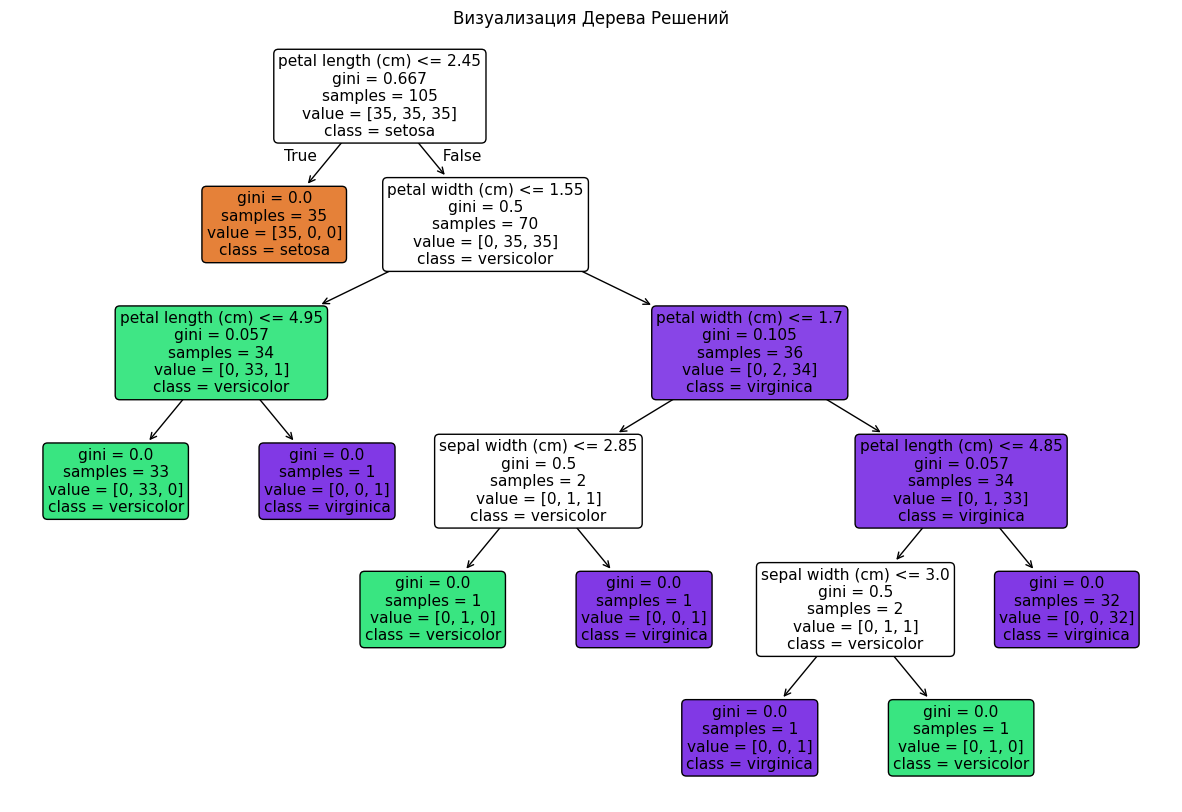


Текстовое представление правил Дерева решений:

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.55
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.55
|   |   |--- petal width (cm) <= 1.70
|   |   |   |--- sepal width (cm) <= 2.85
|   |   |   |   |--- class: 1
|   |   |   |--- sepal width (cm) >  2.85
|   |   |   |   |--- class: 2
|   |   |--- petal width (cm) >  1.70
|   |   |   |--- petal length (cm) <= 4.85
|   |   |   |   |--- sepal width (cm) <= 3.00
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- sepal width (cm) >  3.00
|   |   |   |   |   |--- class: 1
|   |   |   |--- petal length (cm) >  4.85
|   |   |   |   |--- class: 2



In [15]:
# Визуализация дерева решений
plt.figure(figsize=(15, 10))
plot_tree(dt_model, filled=True, feature_names=iris.feature_names, class_names=iris.target_names, rounded=True)
plt.title('Визуализация Дерева Решений')
plt.show()

# Также можно сохранить в файл и отобразить через graphviz (более детализированно для больших деревьев)
dot_data = export_text(dt_model, feature_names=list(iris.feature_names))
print("\nТекстовое представление правил Дерева решений:\n")
print(dot_data)

# Если нужна более интерактивная или красивая визуализация с Graphviz:
# from sklearn.tree import export_graphviz
# dot_data = export_graphviz(dt_model, out_file=None,
#                             feature_names=iris.feature_names,
#                             class_names=iris.target_names,
#                             filled=True, rounded=True,
#                             special_characters=True)
# graph = graphviz.Source(dot_data)
# graph.render("iris_decision_tree", format="png", view=True)
# Image(filename='iris_decision_tree.png')


### Вывод правил дерева решений (текстовый)

In [16]:
tree_rules = export_text(dt_model, feature_names=list(iris.feature_names), class_names=list(iris.target_names))
print("Правила Дерева решений:\n")
print(tree_rules)

Правила Дерева решений:

|--- petal length (cm) <= 2.45
|   |--- class: setosa
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.55
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: versicolor
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: virginica
|   |--- petal width (cm) >  1.55
|   |   |--- petal width (cm) <= 1.70
|   |   |   |--- sepal width (cm) <= 2.85
|   |   |   |   |--- class: versicolor
|   |   |   |--- sepal width (cm) >  2.85
|   |   |   |   |--- class: virginica
|   |   |--- petal width (cm) >  1.70
|   |   |   |--- petal length (cm) <= 4.85
|   |   |   |   |--- sepal width (cm) <= 3.00
|   |   |   |   |   |--- class: virginica
|   |   |   |   |--- sepal width (cm) >  3.00
|   |   |   |   |   |--- class: versicolor
|   |   |   |--- petal length (cm) >  4.85
|   |   |   |   |--- class: virginica

